#Dataset: supermarket_sales.csv

Part A: Confidence Interval Estimation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Dataset Loaded Successfully!

First Five Records:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0  13:08      Ewallet  522.83      

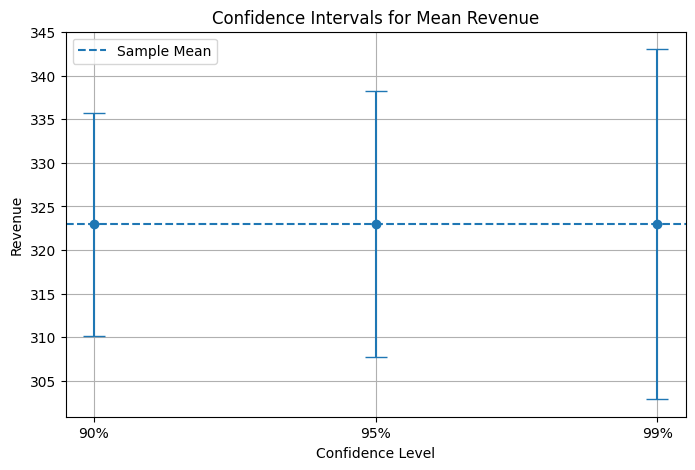


95% Confidence Interval Interpretation:
We are 95% confident that the true population mean revenue lies between 307.71 and 338.23.

Customer Type Proportions:
Customer type
Member    0.501
Normal    0.499
Name: proportion, dtype: float64

Member Customer Proportion:
Number of Members: 501
Total Customers: 1000
Sample Proportion: 0.501

95% Confidence Interval for Member Proportion:
0.47 to 0.532

Percentage: 47.00% to 53.20%

Business Interpretation:
We are 95% confident that the true proportion of Member customers in the supermarket population is between 47.00% and 53.20%.
Sachin Ramesh Mehta


In [4]:
# PART A: CONFIDENCE INTERVAL ESTIMATION
# 1. Load the dataset
df = pd.read_csv("supermarket_sales.csv")

print("Dataset Loaded Successfully!")
print("=" * 60)

# 2. Display first five records and dataset size
print("\nFirst Five Records:")
print(df.head())

print("\nDataset Size:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Prepare revenue column
# If revenue column does not exist, use Total as revenue
if "revenue" not in df.columns:

    if "Revenue" in df.columns:
        df["revenue"] = df["Revenue"]

    elif "Total" in df.columns:
        df["revenue"] = df["Total"]

    elif "total" in df.columns:
        df["revenue"] = df["total"]

    else:
        raise ValueError(
            "Revenue column not found. Please check your CSV column names."
        )

# 3. Select revenue column
revenue = df["revenue"]
print("\nRevenue Column:")
print(revenue.head())

# 4. Check and handle missing values
print("\nMissing Values in Revenue:")
print(revenue.isnull().sum())

# Remove missing values
revenue = revenue.dropna()
print("Missing values after handling:", revenue.isnull().sum())

# 5. Calculate sample size, mean and standard deviation
n = len(revenue)
sample_mean = revenue.mean()
sample_std = revenue.std()

print("\nSample Statistics:")
print("Sample Size:", n)
print("Sample Mean:", round(sample_mean, 2))
print("Sample Standard Deviation:", round(sample_std, 2))


# Function to calculate confidence interval
def confidence_interval(data, confidence):

    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)

    # Standard Error
    se = std / np.sqrt(n)

    # t critical value
    t_value = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin_error = t_value * se

    lower = mean - margin_error
    upper = mean + margin_error

    return lower, upper


# 6. Calculate 90% confidence interval
ci_90 = confidence_interval(revenue, 0.90)

print("\n90% Confidence Interval:")
print("Lower:", round(ci_90[0], 2))
print("Upper:", round(ci_90[1], 2))


# 7. Calculate 95% confidence interval
ci_95 = confidence_interval(revenue, 0.95)

print("\n95% Confidence Interval:")
print("Lower:", round(ci_95[0], 2))
print("Upper:", round(ci_95[1], 2))


# 8. Calculate 99% confidence interval
ci_99 = confidence_interval(revenue, 0.99)

print("\n99% Confidence Interval:")
print("Lower:", round(ci_99[0], 2))
print("Upper:", round(ci_99[1], 2))


# 9. Display confidence intervals in a table
ci_table = pd.DataFrame({
    "Confidence Level": ["90%", "95%", "99%"],
    "Lower Limit": [
        ci_90[0],
        ci_95[0],
        ci_99[0]
    ],
    "Upper Limit": [
        ci_90[1],
        ci_95[1],
        ci_99[1]
    ]
})

print("\nConfidence Interval Table:")
print(ci_table.round(2))


# 10. Compare confidence intervals
print("\nComparison of Confidence Intervals:")
print("90% CI :", round(ci_90[0], 2), "to", round(ci_90[1], 2))
print("95% CI :", round(ci_95[0], 2), "to", round(ci_95[1], 2))
print("99% CI :", round(ci_99[0], 2), "to", round(ci_99[1], 2))

print("\nObservation:")
print("As the confidence level increases, the interval becomes wider.")


# 11. Visualization of sample mean and confidence intervals

levels = ["90%", "95%", "99%"]
lower_values = [ci_90[0], ci_95[0], ci_99[0]]
upper_values = [ci_90[1], ci_95[1], ci_99[1]]

errors_lower = [
    sample_mean - ci_90[0],
    sample_mean - ci_95[0],
    sample_mean - ci_99[0]
]

errors_upper = [
    ci_90[1] - sample_mean,
    ci_95[1] - sample_mean,
    ci_99[1] - sample_mean
]

plt.figure(figsize=(8, 5))

plt.errorbar(
    levels,
    [sample_mean] * 3,
    yerr=[errors_lower, errors_upper],
    fmt='o',
    capsize=8
)

plt.axhline(
    sample_mean,
    linestyle='--',
    label='Sample Mean'
)

plt.title("Confidence Intervals for Mean Revenue")
plt.xlabel("Confidence Level")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()


# 12. Interpretation of 95% confidence interval
print("\n95% Confidence Interval Interpretation:")
print(
    f"We are 95% confident that the true population mean revenue "
    f"lies between {ci_95[0]:.2f} and {ci_95[1]:.2f}."
)


# CUSTOMER TYPE PROPORTION
# 13. Select customer_type column
# Handle different possible column names

if "customer_type" in df.columns:
    customer_type = df["customer_type"]

elif "Customer type" in df.columns:
    customer_type = df["Customer type"]

elif "Customer Type" in df.columns:
    customer_type = df["Customer Type"]

else:
    raise ValueError(
        "Customer type column not found. Check your CSV column name."
    )


# Calculate proportion of each category
customer_proportion = customer_type.value_counts(normalize=True)

print("\nCustomer Type Proportions:")
print(customer_proportion)


# 14. 95% CI for proportion of Member customers

member_count = (customer_type == "Member").sum()
total_customers = customer_type.notna().sum()

p_hat = member_count / total_customers

# Standard error for proportion
se_proportion = np.sqrt(
    (p_hat * (1 - p_hat)) / total_customers
)

# 95% z critical value
z_value = stats.norm.ppf(0.975)

margin_proportion = z_value * se_proportion

proportion_lower = p_hat - margin_proportion
proportion_upper = p_hat + margin_proportion

# Keep values between 0 and 1
proportion_lower = max(0, proportion_lower)
proportion_upper = min(1, proportion_upper)

print("\nMember Customer Proportion:")
print("Number of Members:", member_count)
print("Total Customers:", total_customers)
print("Sample Proportion:", round(p_hat, 4))

print("\n95% Confidence Interval for Member Proportion:")
print(
    round(proportion_lower, 4),
    "to",
    round(proportion_upper, 4)
)

print(
    f"\nPercentage: {proportion_lower * 100:.2f}% "
    f"to {proportion_upper * 100:.2f}%"
)


# 15. Business interpretation
print("\nBusiness Interpretation:")
print(
    f"We are 95% confident that the true proportion of Member "
    f"customers in the supermarket population is between "
    f"{proportion_lower * 100:.2f}% and "
    f"{proportion_upper * 100:.2f}%."
)
print("Sachin Ramesh Mehta") 

PART B: BOOTSTRAPPING


PART B: BOOTSTRAPPING

Original Sample Median:
253.85


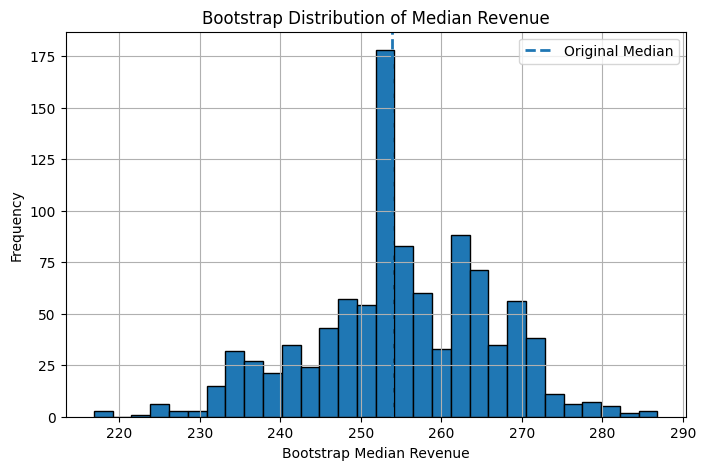


Bootstrap Percentiles:
2.5th Percentile: 232.87
97.5th Percentile: 273.61

95% Bootstrap Confidence Interval:
232.87 to 273.61

Bootstrap Result:
   Original Median  Lower 95% CI  Upper 95% CI
0           253.85        232.87        273.61

Comparison:
Original Median: 253.85
Bootstrap CI: 232.87 to 273.61
The original median lies inside the bootstrap confidence interval.

Business Interpretation:
The bootstrap analysis estimates that the population median revenue is likely to fall between 232.87 and 273.61 with 95% confidence.
Sachin Ramesh Mehta


In [5]:

# 16. Original sample median
original_median = revenue.median()

print("\n" + "=" * 60)
print("PART B: BOOTSTRAPPING")
print("=" * 60)

print("\nOriginal Sample Median:")
print(round(original_median, 2))

# 17-19. Bootstrap sampling
np.random.seed(42)

bootstrap_medians = []

num_bootstrap = 1000

for i in range(num_bootstrap):

    # Select observations with replacement
    bootstrap_sample = np.random.choice(
        revenue,
        size=len(revenue),
        replace=True
    )

    # Calculate median
    bootstrap_median = np.median(bootstrap_sample)

    # Store result
    bootstrap_medians.append(bootstrap_median)


# Convert to NumPy array
bootstrap_medians = np.array(bootstrap_medians)


# 20. Histogram of bootstrap median values
plt.figure(figsize=(8, 5))

plt.hist(
    bootstrap_medians,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    original_median,
    linestyle="--",
    linewidth=2,
    label="Original Median"
)

plt.title("Bootstrap Distribution of Median Revenue")
plt.xlabel("Bootstrap Median Revenue")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()


# 21. Calculate 2.5th and 97.5th percentiles
lower_percentile = np.percentile(
    bootstrap_medians,
    2.5
)

upper_percentile = np.percentile(
    bootstrap_medians,
    97.5
)

print("\nBootstrap Percentiles:")
print("2.5th Percentile:", round(lower_percentile, 2))
print("97.5th Percentile:", round(upper_percentile, 2))


# 22. 95% Bootstrap Confidence Interval
bootstrap_ci = (
    lower_percentile,
    upper_percentile
)

print("\n95% Bootstrap Confidence Interval:")
print(
    round(bootstrap_ci[0], 2),
    "to",
    round(bootstrap_ci[1], 2)
)


# 23. Display original median and bootstrap CI
bootstrap_result = pd.DataFrame({
    "Original Median": [original_median],
    "Lower 95% CI": [bootstrap_ci[0]],
    "Upper 95% CI": [bootstrap_ci[1]]
})

print("\nBootstrap Result:")
print(bootstrap_result.round(2))


# 24. Compare original median with CI
print("\nComparison:")
print("Original Median:", round(original_median, 2))
print(
    "Bootstrap CI:",
    round(bootstrap_ci[0], 2),
    "to",
    round(bootstrap_ci[1], 2)
)

if bootstrap_ci[0] <= original_median <= bootstrap_ci[1]:
    print("The original median lies inside the bootstrap confidence interval.")
else:
    print("The original median lies outside the bootstrap confidence interval.")


# 25. Business interpretation
print("\nBusiness Interpretation:")
print(
    f"The bootstrap analysis estimates that the population median "
    f"revenue is likely to fall between {bootstrap_ci[0]:.2f} "
    f"and {bootstrap_ci[1]:.2f} with 95% confidence."
)

print("Sachin Ramesh Mehta") 